In [3]:
from pathlib import Path
import json
import supervision as sv

In [4]:
DATASET_DIR = Path("C:\\Users\\chris\\Documents\\GitHub\\DINO-LungDet\\data\\processed")  # anpassen falls nötig

TRAIN_IMAGES = DATASET_DIR / "train" / "images"
TRAIN_LABELS = DATASET_DIR / "train" / "labels"

VAL_IMAGES = DATASET_DIR / "val" / "images"
VAL_LABELS = DATASET_DIR / "val" / "labels"

TEST_IMAGES = DATASET_DIR / "test" / "images"
TEST_LABELS = DATASET_DIR / "test" / "labels"

EXPORT_DIR = DATASET_DIR / "coco"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
CLASS_NAMES = ["nodule"]   # anpassen, falls deine Klasse anders heißt

In [12]:
train_ds = sv.DetectionDataset.from_yolo(
    images_directory_path=str(TRAIN_IMAGES),
    annotations_directory_path=str(TRAIN_LABELS),
    data_yaml_path=str(DATASET_DIR / "data.yaml"),
)


In [10]:

val_ds = sv.DetectionDataset.from_yolo(
    images_directory_path=str(VAL_IMAGES),
    annotations_directory_path=str(VAL_LABELS),
    data_yaml_path=str(DATASET_DIR / "data.yaml"),
)


In [11]:

test_ds = sv.DetectionDataset.from_yolo(
    images_directory_path=str(TEST_IMAGES),
    annotations_directory_path=str(TEST_LABELS),
    data_yaml_path=str(DATASET_DIR / "data.yaml"),
)

In [13]:
print("Train:", len(train_ds))
print("Val:", len(val_ds))
print("Test:", len(test_ds))

Train: 21883
Val: 4106
Test: 4393


In [15]:
sample_image_name, sample_image, sample_annotations = next(iter(train_ds))

print("Image name:", sample_image_name)
print("Image shape:", sample_image.shape)
print(sample_annotations)

Image name: C:\Users\chris\Documents\GitHub\DINO-LungDet\data\processed\train\images\A0001_1.3.6.1.4.1.14519.5.2.1.6655.2359.102500633407588554681658808214_16bit.png
Image shape: (512, 512, 3)
Detections(xyxy=array([[286.00012, 309.9996 , 355.0003 , 401.99988]], dtype=float32), mask=None, confidence=None, class_id=array([0]), tracker_id=None, data={}, metadata={})


In [16]:
print("xyxy boxes:")
print(sample_annotations.xyxy)

print("class ids:")
print(sample_annotations.class_id)

xyxy boxes:
[[286.00012 309.9996  355.0003  401.99988]]
class ids:
[0]


In [17]:
train_coco = train_ds.as_coco(annotations_path=str(EXPORT_DIR / "train_annotations.coco.json"))
val_coco = val_ds.as_coco(annotations_path=str(EXPORT_DIR / "val_annotations.coco.json"))
test_coco = test_ds.as_coco(annotations_path=str(EXPORT_DIR / "test_annotations.coco.json"))

In [18]:
print("Exported:")
print(EXPORT_DIR / "train_annotations.coco.json")
print(EXPORT_DIR / "val_annotations.coco.json")
print(EXPORT_DIR / "test_annotations.coco.json")

Exported:
C:\Users\chris\Documents\GitHub\DINO-LungDet\data\processed\coco\train_annotations.coco.json
C:\Users\chris\Documents\GitHub\DINO-LungDet\data\processed\coco\val_annotations.coco.json
C:\Users\chris\Documents\GitHub\DINO-LungDet\data\processed\coco\test_annotations.coco.json


In [19]:
with open(EXPORT_DIR / "train_annotations.coco.json", "r", encoding="utf-8") as f:
    train_coco_json = json.load(f)

print(train_coco_json.keys())
print("num images:", len(train_coco_json["images"]))
print("num annotations:", len(train_coco_json["annotations"]))
print("categories:", train_coco_json["categories"][:5])

dict_keys(['info', 'licenses', 'categories', 'images', 'annotations'])
num images: 21883
num annotations: 21954
categories: [{'id': 0, 'name': 'nodule', 'supercategory': 'common-objects'}]


In [20]:
print("first image entry:")
print(train_coco_json["images"][0])

print("\nfirst annotation entry:")
print(train_coco_json["annotations"][0])

first image entry:
{'id': 1, 'license': 1, 'file_name': 'A0001_1.3.6.1.4.1.14519.5.2.1.6655.2359.102500633407588554681658808214_16bit.png', 'height': 512, 'width': 512, 'date_captured': '03/12/2026,17:59:09'}

first annotation entry:
{'id': 1, 'image_id': 1, 'category_id': 0, 'bbox': [286.0001220703125, 309.9996032714844, 69.00018310546875, 92.00027465820312], 'area': 6348.03564453125, 'segmentation': [], 'iscrowd': 0}


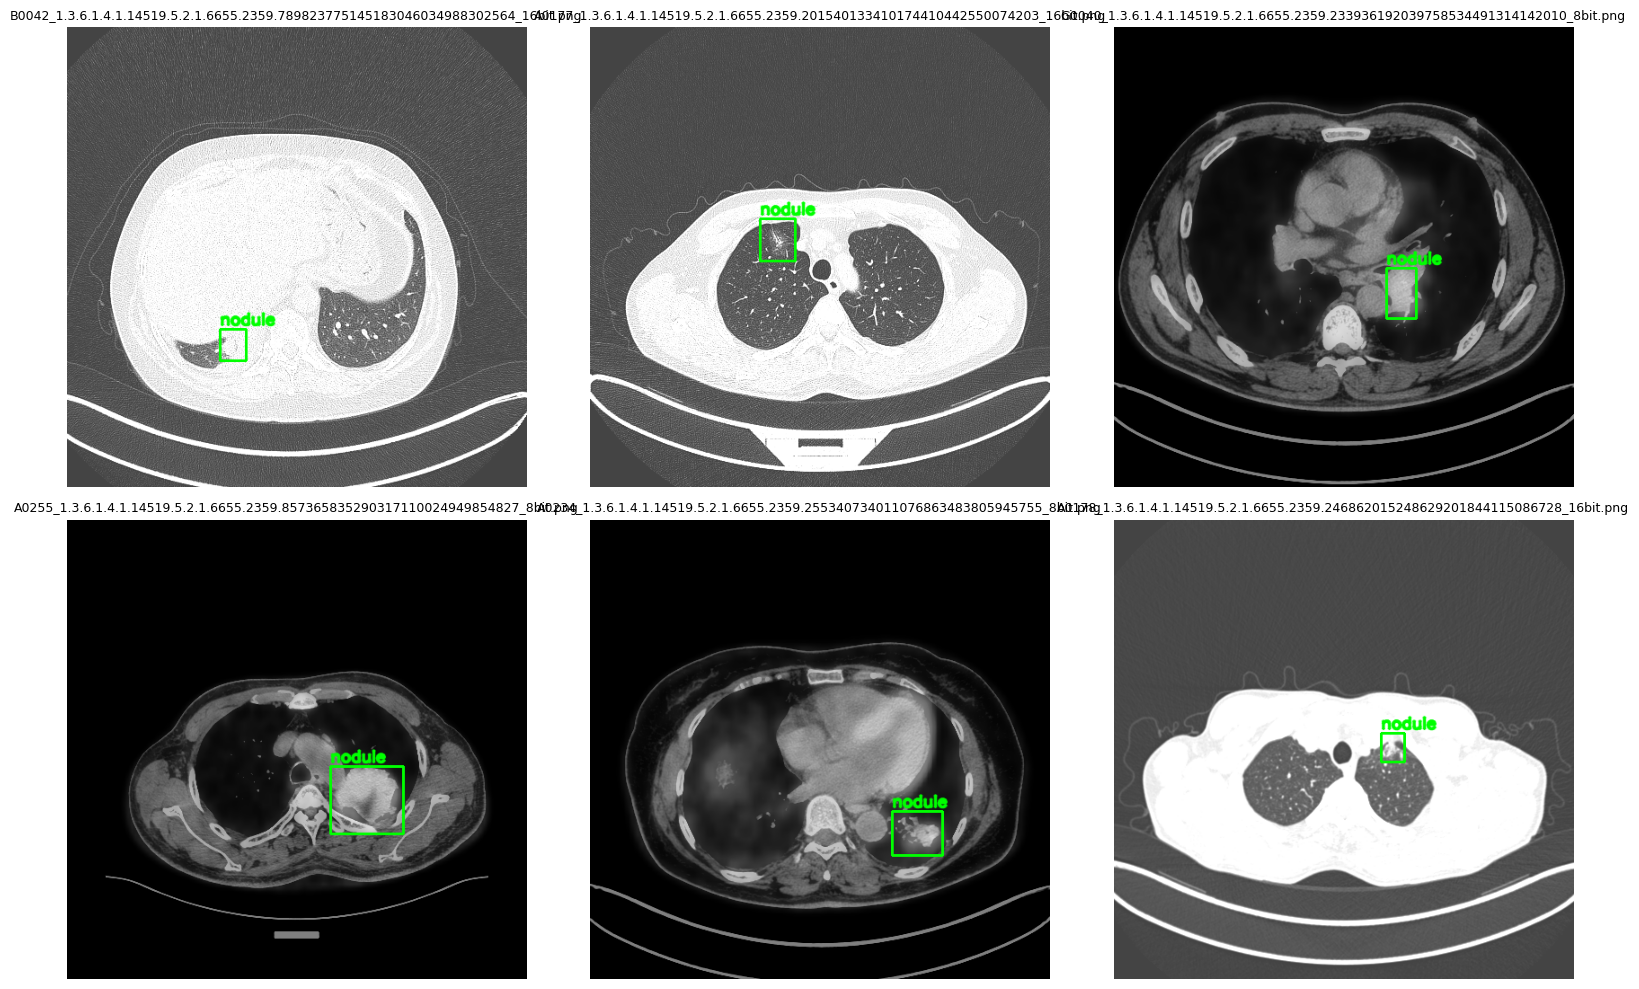

In [24]:
import random
import json
import cv2
import matplotlib.pyplot as plt

with open(EXPORT_DIR / "train_annotations.coco.json", "r", encoding="utf-8") as f:
    coco = json.load(f)

category_map = {cat["id"]: cat["name"] for cat in coco["categories"]}

sample_images = random.sample(coco["images"], k=min(6, len(coco["images"])))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, image_entry in zip(axes, sample_images):
    image_id = image_entry["id"]
    file_name = image_entry["file_name"]
    anns = [ann for ann in coco["annotations"] if ann["image_id"] == image_id]

    image_path = TRAIN_IMAGES / file_name
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    for ann in anns:
        x, y, w, h = ann["bbox"]
        x1, y1 = int(x), int(y)
        x2, y2 = int(x + w), int(y + h)

        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)

        label = category_map[ann["category_id"]]
        cv2.putText(
            image,
            label,
            (x1, max(20, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2,
            cv2.LINE_AA,
        )

    ax.imshow(image)
    ax.set_title(file_name, fontsize=9)
    ax.axis("off")

for i in range(len(sample_images), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [25]:
import json
import numpy as np

with open(EXPORT_DIR / "train_annotations.coco.json", "r", encoding="utf-8") as f:
    coco = json.load(f)

num_images = len(coco["images"])
num_annotations = len(coco["annotations"])

boxes = np.array([ann["bbox"] for ann in coco["annotations"]], dtype=float)  # x, y, w, h
widths = boxes[:, 2]
heights = boxes[:, 3]
areas = widths * heights

image_ids_with_ann = {ann["image_id"] for ann in coco["annotations"]}
images_without_ann = [img["id"] for img in coco["images"] if img["id"] not in image_ids_with_ann]

print("num_images:", num_images)
print("num_annotations:", num_annotations)
print("images_without_annotations:", len(images_without_ann))

print("bbox width  min/mean/max:", widths.min(), widths.mean(), widths.max())
print("bbox height min/mean/max:", heights.min(), heights.mean(), heights.max())
print("bbox area   min/mean/max:", areas.min(), areas.mean(), areas.max())

num_images: 21883
num_annotations: 21954
images_without_annotations: 0
bbox width  min/mean/max: 7.000068664550781 53.41910254183152 191.0000762939453
bbox height min/mean/max: 8.999923706054688 58.83009994317786 188.000244140625
bbox area   min/mean/max: 63.000083918101154 3636.215793310419 33839.995178159326


In [26]:
from torchvision.datasets import CocoDetection

train_raw = CocoDetection(
    root=str(TRAIN_IMAGES),
    annFile=str(EXPORT_DIR / "train_annotations.coco.json"),
)

val_raw = CocoDetection(
    root=str(VAL_IMAGES),
    annFile=str(EXPORT_DIR / "val_annotations.coco.json"),
)

test_raw = CocoDetection(
    root=str(TEST_IMAGES),
    annFile=str(EXPORT_DIR / "test_annotations.coco.json"),
)

print("Train:", len(train_raw))
print("Val:", len(val_raw))
print("Test:", len(test_raw))

loading annotations into memory...
Done (t=0.12s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
Train: 21883
Val: 4106
Test: 4393


In [27]:
sample_img, sample_target = train_raw[0]

print(type(sample_img))
print(type(sample_target))
print("num annotations:", len(sample_target))
print(sample_target[0])

<class 'PIL.Image.Image'>
<class 'list'>
num annotations: 1
{'id': 1, 'image_id': 1, 'category_id': 0, 'bbox': [286.0001220703125, 309.9996032714844, 69.00018310546875, 92.00027465820312], 'area': 6348.03564453125, 'segmentation': [], 'iscrowd': 0}


In [28]:
from torchvision.datasets import wrap_dataset_for_transforms_v2

train_wrapped = wrap_dataset_for_transforms_v2(train_raw, target_keys=("boxes", "labels", "image_id"))
val_wrapped = wrap_dataset_for_transforms_v2(val_raw, target_keys=("boxes", "labels", "image_id"))
test_wrapped = wrap_dataset_for_transforms_v2(test_raw, target_keys=("boxes", "labels", "image_id"))

In [29]:
sample_img, sample_target = train_wrapped[0]

print(type(sample_img))
print(type(sample_target))
print(sample_target.keys())
print(sample_target["boxes"])
print(sample_target["labels"])

<class 'PIL.Image.Image'>
<class 'dict'>
dict_keys(['image_id', 'boxes', 'labels'])
BoundingBoxes([[286.0001, 309.9996, 355.0003, 401.9999]], format=BoundingBoxFormat.XYXY, canvas_size=(512, 512), clamping_mode=soft)
tensor([0])


In [31]:
from torchvision.transforms import v2 as T
import torch


train_transforms = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
])

eval_transforms = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
])